In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [5]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 20 

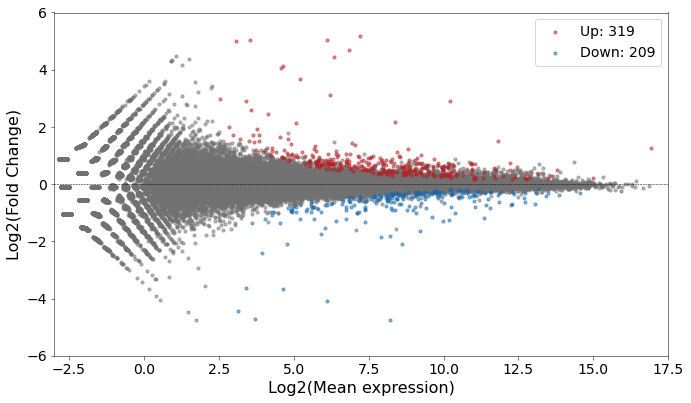

In [ ]:
# DESeq2 output
df = pd.read_csv("rna_seq/DESeq2_1.18.1.Experimental_VS_Control.alpha01.tsv", sep="\t")
for col in ['baseMean', 'log2FoldChange', 'padj', 'log2FoldChange.shrunk']:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

df = df[df['baseMean'] > 0]
df['sign'] = df['sign'].str.lower()

is_up = df['sign'] == 'up'
is_down = df['sign'] == 'down'
is_other = ~(is_up | is_down)

plt.figure(figsize=(10, 6))
plt.scatter(np.log2(df.loc[is_other, 'baseMean']),
            df.loc[is_other, 'log2FoldChange'],
            color='#717171', s=10, alpha=0.5, rasterized=True)
plt.scatter(np.log2(df.loc[is_up, 'baseMean']),
            df.loc[is_up, 'log2FoldChange'],
            color='#B22125', s=10, alpha=0.5, label=f"Up: {is_up.sum()}", rasterized=True)
plt.scatter(np.log2(df.loc[is_down, 'baseMean']),
            df.loc[is_down, 'log2FoldChange'],
            color='#1766ab', s=10, alpha=0.5, label=f"Down: {is_down.sum()}", rasterized=True)

# to label the genes of interest:

# genes_to_label = ["Chd1"]

# for _, row in df[df['gene_name'].isin(genes_to_label)].iterrows():
#     x = np.log2(row['baseMean'])
#     y = row['log2FoldChange']
    
# Adjust label position (e.g., offset to the top-right)
# offset_x = 0.2
# offset_y = -0.6

    # plt.annotate(
    #     row['gene_name'],                     # text
    #     xy=(x, y),                             # point to annotate
    #     xytext=(x + offset_x, y + offset_y),   # label position
    #     textcoords='data',
    #     fontsize=10,
    #     ha='left',
    #     va='bottom',
    #     bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='black', lw=0.5),
    #     arrowprops=dict(arrowstyle='-', color='black', lw=0.5)
    # )
    
ax = plt.gca()

# Thinner frame lines)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(width=0.5)
    
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.xlabel("Log2(Mean expression)", fontsize=16)
plt.ylabel("Log2(Fold Change)", fontsize=16)
#plt.title("MA Plot with Gene Labels")
plt.ylim(-6, 6)
plt.xlim(-3, 17.5)
plt.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()

plt.show()

# plt.savefig("DeSeq2_MA_plot_FDR01.pdf", dpi=300, bbox_inches="tight", pad_inches=1)
